In [1]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
# generate two class dataset
X, y = make_classification(n_samples=1000, n_classes=2, n_features=20, random_state=27)

# split into train_test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=27)


In [6]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.258203,1.019808,1.524563,0.617243,0.148243,0.744111,-0.363963,1.549367,0.256960,-1.222225,0.636587,1.448634,-1.471582,1.918621,2.584944,2.638990,0.069881,0.332721,-0.175407,1.501124
1,-0.458166,0.828728,-0.656965,-0.056297,0.254895,-0.018241,0.313829,-0.386936,-1.632152,-2.059698,0.356881,-1.400478,0.326012,1.058607,-0.668410,-0.622784,-0.405360,1.201937,-0.255835,-0.199313
2,-0.387378,0.761818,-1.310351,-0.351663,-0.130643,-0.641420,0.152001,0.941251,1.381526,-1.803593,0.749451,0.325846,0.742814,0.981221,-1.600239,-1.550548,-0.232538,-1.033209,-1.686671,-0.766836
3,-2.394585,-0.036724,1.361228,-0.371470,1.871835,-1.226815,0.770733,-0.566035,0.688286,1.052618,-1.122666,-0.028873,0.498517,-1.113630,1.640086,1.585018,-1.921666,-1.177293,-1.784434,0.132557
4,0.258229,-1.600952,1.101282,1.659578,0.927923,-0.093182,-1.778309,0.485978,-0.918154,-0.765634,0.601260,0.776797,0.182804,-0.963276,1.312165,1.265336,0.709714,-1.534325,0.698777,-1.625380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.724879,0.281545,-0.362035,-2.602418,0.699501,-0.328376,0.383521,-0.072851,-2.225106,-0.386934,1.686867,1.831139,-0.426400,1.068455,-0.253722,-0.210847,0.358016,-1.335716,-0.871125,0.658246
996,2.085897,0.461640,0.372497,-1.838814,0.024923,-0.710831,-0.945424,1.671489,-0.238396,-0.446206,0.747034,-1.104464,1.774805,-0.657410,0.365474,0.337514,0.676548,-0.623767,-0.985299,0.067141
997,-0.547793,-0.674539,-0.834644,1.050191,-0.797763,0.699879,-0.943583,-0.083061,1.525375,0.938323,-0.449004,-0.343585,0.145134,1.038857,-0.921502,-0.874723,1.315291,0.578216,-1.172548,1.083019
998,0.559619,-0.625025,1.404538,0.593826,-0.270234,-0.519678,-1.407141,1.923672,-0.161268,-1.092994,-0.534942,-1.230007,-0.821936,-1.078008,1.709057,1.654835,0.732973,-1.669515,-0.292760,0.484569


In [7]:
pd.DataFrame(y)

,0
0,1
1,1
2,1
3,0
4,0
...,...
995,1
996,0
997,1
998,0


In [9]:
# train models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [10]:
# logistic regression
model1 = LogisticRegression()

# knn
model2 = KNeighborsClassifier(n_neighbors=4)

In [11]:
# fit model
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [12]:
# predict probabilities
pred_prob1 = model1.predict_proba(X_test)
pred_prob2 = model2.predict_proba(X_test)

## sklearn has a very strong method, roc_curve(), which computes the ROC for your classifier in a matter of seconds! it returns the FPR, TPR, and threshold values.

In [13]:
from sklearn.metrics import roc_curve

In [14]:
# roc curve for models
fpr1, tpr1, thresh1 = roc_curve(y_test, pred_prob1[:, 1], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, pred_prob2[:, 1], pos_label=1)

In [15]:
# roc curve for tpr = fpr
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)


## The AUC score can be computed using the roc_auc_score() method of sklearn.

In [16]:
from sklearn.metrics import roc_auc_score

In [17]:
auc_score1 = roc_auc_score(y_test, pred_prob1[:, 1])
auc_score2 = roc_auc_score(y_test, pred_prob2[:, 1])

In [20]:
print(auc_score1, auc_score2)

0.9762374461979914 0.9233769727403157


## we can also plot the receiver operating characteristics curves(roc) for the two algorithms using matplotlib.

In [23]:
import matplotlib.pyplot as plt

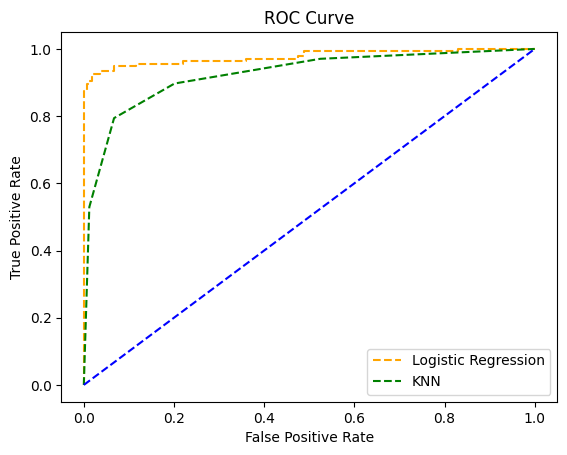

In [25]:
# plot roc curves
plt.plot(fpr1, tpr1, linestyle='--', color='orange', label='Logistic Regression')
plt.plot(fpr2, tpr2, linestyle='--', color='green', label='KNN')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='best')

# It is evident from the plot that the AUC for the Logistic Regression ROC curve is higher than that for the KNN ROC curve. Therefore, we can say that logistic regression did a better job of classifying the positive class in the dataset.